## Model comparison

In [2]:
import pandas as pd

model_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "ROC-AUC": 0.9840,
        "PR-AUC": 0.9404,
        "Precision": 0.7964,
        "Recall": 0.9514,
        "F1-score": 0.8670,
        "False Positives": 45,
        "False Negatives": 9
    },
    {
        "Model": "Random Forest",
        "ROC-AUC": 0.9924,
        "PR-AUC": 0.9629,
        "Precision": 0.9462,
        "Recall": 0.9514,
        "F1-score": 0.9488,
        "False Positives": 10,
        "False Negatives": 9
    },
    {
        "Model": "XGBoost",
        "ROC-AUC": 0.9912,
        "PR-AUC": 0.9604,
        "Precision": 0.9471,
        "Recall": 0.9676,
        "F1-score": 0.9572,
        "False Positives": 10,
        "False Negatives": 6
    }
])

model_results

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1-score,False Positives,False Negatives
0,Logistic Regression,0.9840,0.9404,0.7964,0.9514,0.8670,45,9
1,Random Forest,0.9924,0.9629,0.9462,0.9514,0.9488,10,9
2,XGBoost,0.9912,0.9604,0.9471,0.9676,0.9572,10,6


In [3]:
metrics = ["ROC-AUC", "PR-AUC", "Precision", "Recall", "F1-score"]

ranking = model_results[["Model"] + metrics].copy()

for metric in metrics:
    ranking[f"{metric} Rank"] = ranking[metric].rank(
        ascending=False,
        method="min"
    ).astype(int)

ranking

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1-score,ROC-AUC Rank,PR-AUC Rank,Precision Rank,Recall Rank,F1-score Rank
0,Logistic Regression,0.9840,0.9404,0.7964,0.9514,0.8670,3,3,3,2,3
1,Random Forest,0.9924,0.9629,0.9462,0.9514,0.9488,1,1,2,2,2
2,XGBoost,0.9912,0.9604,0.9471,0.9676,0.9572,2,2,1,1,1


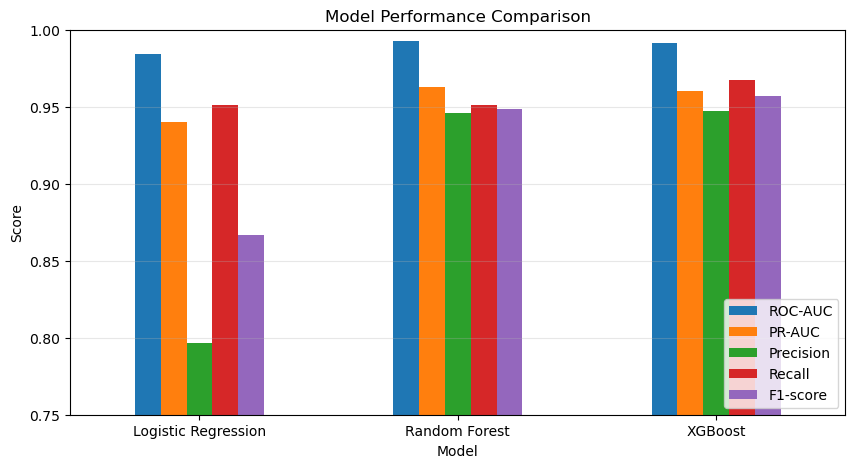

In [4]:
import matplotlib.pyplot as plt

plot_df = model_results.set_index("Model")[metrics]

plot_df.plot(kind="bar", figsize=(10, 5))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.75, 1.00)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.show()

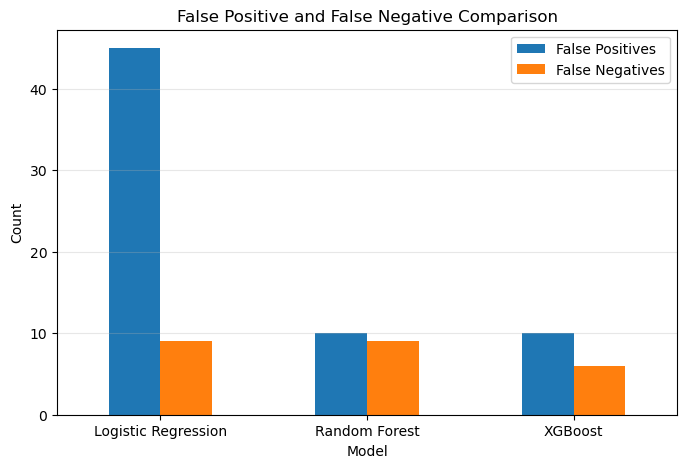

In [5]:
error_df = model_results.set_index("Model")[["False Positives", "False Negatives"]]

error_df.plot(kind="bar", figsize=(8, 5))

plt.title("False Positive and False Negative Comparison")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

### Model Comparison Interpretation

All 3 models performed strongly on the same Kitchener test set, but their strengths are slightly different.

**Random Forest** achieved the highest **ROC-AUC (0.9924)** and **PR-AUC (0.9629)**, which suggests it has the strongest overall ability to separate break and no-break pipes and rank risky pipes correctly.

**XGBoost** achieved the highest **Recall (0.9676)** and **F1-score (0.9572)**, with the fewest false negatives (**6 missed break pipes**). This is important for a risk identification system because missing high-risk pipes may be more costly than flagging a small number of extra pipes.

**Logistic Regression** performed well as a simple baseline, but it had lower **Precision (0.7964)** and **F1-score (0.8670)**. This means it detected many break pipes, but produced more false positives compared with Random Forest and XGBoost.

Overall, **Random Forest and XGBoost are the strongest models**. Random Forest is slightly stronger for overall ranking performance, while XGBoost may be more practical for operational risk screening because it catches more actual break cases.

### Final Model Selection

Based on the comparison:

- XGBoost is selected as the most operationally effective model due to its highest Recall and lowest false negatives
- Random Forest is also retained as a strong benchmark for overall ranking performance
- Logistic Regression is used as a baseline model only

However, the trained models will not be directly applied to Melbourne data.

Instead, the next step is to extract and consolidate key risk drivers from these models and adapt them into a Melbourne risk identification framework.

## Consolidated Risk Drivers for Melbourne Adaptation

The next step is to consolidate the strongest and most consistent risk drivers across the models, then adapt them to the Melbourne water main dataset.

Since Melbourne does not currently have the same confirmed `has_break` target, the Kitchener model should not be directly retrained on Melbourne data. Instead, the findings will be used to build an interpretable Melbourne risk identification framework.

This framework can assign each Melbourne pipe a **High / Medium / Low risk level** or a continuous risk score based on transferable fields such as:

- pipe age from `DATE_OF_CONSTRUCTION`
- material from `MATERIAL`
- pipe length from `PIPE_LENGTH`
- pipe width from `PIPE_WIDTH`
- soil type from `SOIL_TYPE`
- operational context such as `SUBAREA`, `MAIN_CLASS`, and `MAIN_LINE_TYPE`
- relining information from `DATE_RELINED`

The final Melbourne risk output can then be used as input for the LLM component to generate maintenance recommendations and plain-English explanations.

In [9]:
risk_drivers = pd.DataFrame([
    {
        "Risk Driver": "Pipe Age",
        "Evidence from Kitchener Models": "Important in tree-based models and linked to deterioration over time",
        "Melbourne Field": "PIPE_AGE",
        "Transferability": "High",
        "Use in Melbourne Risk System": "Older pipes receive higher risk weight"
    },
    {
        "Risk Driver": "Pipe Length",
        "Evidence from Kitchener Models": "Strong driver in Random Forest and Logistic Regression",
        "Melbourne Field": "PIPE_LENGTH",
        "Transferability": "High",
        "Use in Melbourne Risk System": "Longer pipe segments receive higher risk weight"
    },
    {
        "Risk Driver": "Material",
        "Evidence from Kitchener Models": "Material-related features contributed to prediction",
        "Melbourne Field": "MATERIAL",
        "Transferability": "High",
        "Use in Melbourne Risk System": "Materials associated with higher failure risk receive higher weight"
    },
    {
        "Risk Driver": "Pipe Size / Width",
        "Evidence from Kitchener Models": "Moderate contribution in Random Forest",
        "Melbourne Field": "PIPE_WIDTH",
        "Transferability": "Medium",
        "Use in Melbourne Risk System": "Used as a supporting physical risk factor"
    },
    {
        "Risk Driver": "Condition / Asset Health",
        "Evidence from Kitchener Models": "Strongest Random Forest driver through condition_score",
        "Melbourne Field": "Not directly available",
        "Transferability": "Limited",
        "Use in Melbourne Risk System": "Use proxy features such as age and relining status"
    },
    {
        "Risk Driver": "Relining / Maintenance History",
        "Evidence from Kitchener Models": "Lining-related features had lower importance but are still relevant",
        "Melbourne Field": "HAS_RELINED, YEARS_SINCE_RELINED",
        "Transferability": "Medium",
        "Use in Melbourne Risk System": "No relining or older relining may increase risk"
    },
    {
        "Risk Driver": "Network / Operational Context",
        "Evidence from Kitchener Models": "Pressure zone and cleaning area contributed to prediction",
        "Melbourne Field": "MAIN_LINE_TYPE, MAIN_CLASS, FIELD_TEAM",
        "Transferability": "Medium",
        "Use in Melbourne Risk System": "Used as context to support risk explanation and grouping"
    }
])

risk_drivers

,Risk Driver,Evidence from Kitchener Models,Melbourne Field,Transferability,Use in Melbourne Risk System
0,Pipe Age,Important in tree-based models and linked to d...,PIPE_AGE,High,Older pipes receive higher risk weight
1,Pipe Length,Strong driver in Random Forest and Logistic Re...,PIPE_LENGTH,High,Longer pipe segments receive higher risk weight
2,Material,Material-related features contributed to predi...,MATERIAL,High,Materials associated with higher failure risk ...
3,Pipe Size / Width,Moderate contribution in Random Forest,PIPE_WIDTH,Medium,Used as a supporting physical risk factor
4,Condition / Asset Health,Strongest Random Forest driver through conditi...,Not directly available,Limited,Use proxy features such as age and relining st...
5,Relining / Maintenance History,Lining-related features had lower importance b...,"HAS_RELINED, YEARS_SINCE_RELINED",Medium,No relining or older relining may increase risk
6,Network / Operational Context,Pressure zone and cleaning area contributed to...,"MAIN_LINE_TYPE, MAIN_CLASS, FIELD_TEAM",Medium,Used as context to support risk explanation an...


### Risk Driver Summary

The most transferable risk drivers from Kitchener to Melbourne are **Pipe Age, Pipe Length, Material, and Pipe Width**, because these fields are available in both contexts or can be directly derived.

The main limitation is **Condition Score**, which was the strongest Kitchener driver but is not available in the Melbourne dataset. For Melbourne, condition-related risk will therefore be approximated using proxy features such as pipe age and relining status.

Network and operational context fields are not exact matches, but they can still support grouping, explanation, and later LLM recommendations.

## Melbourne Risk Scoring Framework

This section converts the consolidated Kitchener findings into a simple Melbourne risk scoring framework.

Because Melbourne does not have a confirmed failure label, this is not a supervised prediction model. Instead, each pipe is assigned a risk score based on transferable risk drivers, then classified as Low, Medium, or High risk.

In [12]:
import pandas as pd

melbourne_scored = pd.read_csv("../data/processed/melbourne_cleaned_for_adaptation.csv")

print("Shape:", melbourne_scored.shape)
display(melbourne_scored.head())

Shape: (12677, 24)


,ASSET_ID,COMPKEY,UNITID,UNITID2,MAIN_NAME,MAIN_LINE_TYPE,MAIN_CLASS,MATERIAL,PIPE_LENGTH,PIPE_WIDTH,...,HAS_RELINED,YEARS_SINCE_RELINED,MISSING_RELINED_DATE,INVALID_PIPE_LENGTH,INVALID_PIPE_WIDTH,FUTURE_RELINED_DATE,FIELD_TEAM,SERVICE_STATUS,COMMENTS,DATE_LAST_UPDATED
0,M474,296455,M474-00374BR,M474-00377BR,ST GEORGES RD REPLACEMENT MAIN,MAINBG,T,MSCL,2.72,1400.0,...,0,0.0,1,0,0,0,PRESTON,IN,NO COMMENT,2018-09-26 12:31:01
1,Z060,293331,WZ060-ZA,WZ060T101,CARDINIA CREEK MINI HYDRO,MAINAG,S,MSCL,1.88,225.0,...,0,0.0,1,0,0,0,SILVAN,IN,NO COMMENT,2018-03-01 14:04:45
2,M281,1017825,WZ060-01040BR,M281V-EB,CARDINIA-DAND'G-NOTTING HILL M,BYPASS,S,MSCL,1.74,225.0,...,0,0.0,1,0,0,0,SILVAN,IN,NO COMMENT,2018-02-27 00:00:00
3,R144,234582,WR144V-R,WR144-0-0019,TYABB RESERVOIR,MAINBG,S,MS,131.30,100.0,...,0,0.0,1,0,0,0,WESTERNPORT,IN,STORAGE CLEANING PIPE,2018-07-23 12:11:24
4,M281,227935,M281V-EA,WZ060-01040BR,CARDINIA-DAND'G-NOTTING HILL M,BYPASS,S,MSCL,5.26,225.0,...,0,0.0,1,0,0,0,SILVAN,IN,NO COMMENT,2018-02-27 00:00:00


In [13]:
# Start with zero risk score
melbourne_scored["RISK_SCORE"] = 0

# Age risk
melbourne_scored.loc[melbourne_scored["PIPE_AGE"] >= 80, "RISK_SCORE"] += 3
melbourne_scored.loc[
    (melbourne_scored["PIPE_AGE"] >= 50) & (melbourne_scored["PIPE_AGE"] < 80),
    "RISK_SCORE"
] += 2
melbourne_scored.loc[
    (melbourne_scored["PIPE_AGE"] >= 30) & (melbourne_scored["PIPE_AGE"] < 50),
    "RISK_SCORE"
] += 1

# Missing construction date adds uncertainty
melbourne_scored.loc[melbourne_scored["MISSING_CONSTRUCTION_DATE"] == 1, "RISK_SCORE"] += 1

# Pipe length risk
length_75 = melbourne_scored["PIPE_LENGTH"].quantile(0.75)
length_90 = melbourne_scored["PIPE_LENGTH"].quantile(0.90)

melbourne_scored.loc[melbourne_scored["PIPE_LENGTH"] >= length_90, "RISK_SCORE"] += 2
melbourne_scored.loc[
    (melbourne_scored["PIPE_LENGTH"] >= length_75) & (melbourne_scored["PIPE_LENGTH"] < length_90),
    "RISK_SCORE"
] += 1

# Material risk
higher_risk_materials = ["CI", "CICL", "AC", "RC"]

melbourne_scored.loc[
    melbourne_scored["MATERIAL"].isin(higher_risk_materials),
    "RISK_SCORE"
] += 2

# Relining risk
melbourne_scored.loc[melbourne_scored["HAS_RELINED"] == 0, "RISK_SCORE"] += 1
melbourne_scored.loc[melbourne_scored["YEARS_SINCE_RELINED"] >= 50, "RISK_SCORE"] += 1

# Data quality risk
melbourne_scored.loc[melbourne_scored["INVALID_PIPE_LENGTH"] == 1, "RISK_SCORE"] += 1
melbourne_scored.loc[melbourne_scored["INVALID_PIPE_WIDTH"] == 1, "RISK_SCORE"] += 1
melbourne_scored.loc[melbourne_scored["FUTURE_RELINED_DATE"] == 1, "RISK_SCORE"] += 1

# Assign risk level
melbourne_scored["RISK_LEVEL"] = pd.cut(
    melbourne_scored["RISK_SCORE"],
    bins=[-1, 2, 5, 100],
    labels=["LOW", "MEDIUM", "HIGH"]
)

display(melbourne_scored[[
    "ASSET_ID",
    "COMPKEY",
    "MATERIAL",
    "PIPE_LENGTH",
    "PIPE_WIDTH",
    "PIPE_AGE",
    "HAS_RELINED",
    "YEARS_SINCE_RELINED",
    "RISK_SCORE",
    "RISK_LEVEL"
]].head())

melbourne_scored["RISK_LEVEL"].value_counts()

,ASSET_ID,COMPKEY,MATERIAL,PIPE_LENGTH,PIPE_WIDTH,PIPE_AGE,HAS_RELINED,YEARS_SINCE_RELINED,RISK_SCORE,RISK_LEVEL
0,M474,296455,MSCL,2.72,1400.0,9.0,0,0.0,1,LOW
1,Z060,293331,MSCL,1.88,225.0,9.0,0,0.0,1,LOW
2,M281,1017825,MSCL,1.74,225.0,15.0,0,0.0,1,LOW
3,R144,234582,MS,131.30,100.0,9.0,0,0.0,2,LOW
4,M281,227935,MSCL,5.26,225.0,15.0,0,0.0,1,LOW


RISK_LEVEL
LOW       6938
MEDIUM    5137
HIGH       602
Name: count, dtype: int64

### Risk Scoring Output Summary

The Melbourne risk scoring framework classified most pipes as Low or Medium risk, with a smaller group of 602 pipes classified as High risk.

This is useful for maintenance prioritisation because it creates a focused shortlist of higher-risk pipe segments for further review.

The score is based on transferable Kitchener risk drivers, including pipe age, pipe length, material, relining status, and data quality flags. Since Melbourne does not have confirmed failure labels, this should be interpreted as a relative risk identification framework rather than a supervised prediction result.

In [15]:
# Show top high-risk pipes
high_risk_pipes = melbourne_scored[melbourne_scored["RISK_LEVEL"] == "HIGH"].sort_values(
    by="RISK_SCORE",
    ascending=False
)

display(high_risk_pipes[[
    "ASSET_ID",
    "COMPKEY",
    "MAIN_NAME",
    "MATERIAL",
    "PIPE_LENGTH",
    "PIPE_WIDTH",
    "PIPE_AGE",
    "HAS_RELINED",
    "YEARS_SINCE_RELINED",
    "RISK_SCORE",
    "RISK_LEVEL"
]].head(20))

,ASSET_ID,COMPKEY,MAIN_NAME,MATERIAL,PIPE_LENGTH,PIPE_WIDTH,PIPE_AGE,HAS_RELINED,YEARS_SINCE_RELINED,RISK_SCORE,RISK_LEVEL
4833,M421,231587,BITTERN - DROMANA NO 1 MAIN,RC,520.13,675.0,86.0,0,0.0,8,HIGH
2722,M421,231593,BITTERN - DROMANA NO 1 MAIN,RC,300.85,675.0,86.0,0,0.0,8,HIGH
4134,M421,236321,BITTERN - DROMANA NO 1 MAIN,RC,830.75,525.0,86.0,0,0.0,8,HIGH
8789,M421,231592,BITTERN - DROMANA NO 1 MAIN,RC,305.28,525.0,86.0,0,0.0,8,HIGH
9842,A014,226689,TARAGO MAIN RACE,RC,910.02,600.0,75.0,0,0.0,8,HIGH
9837,A014,226696,TARAGO MAIN RACE,RC,241.23,600.0,75.0,0,0.0,8,HIGH
379,M421,236323,BITTERN - DROMANA NO 1 MAIN,RC,571.39,675.0,86.0,0,0.0,8,HIGH
7399,M421,231596,BITTERN - DROMANA NO 1 MAIN,RC,826.05,525.0,86.0,0,0.0,8,HIGH
4403,M421,236326,BITTERN - DROMANA NO 1 MAIN,RC,459.70,525.0,86.0,0,0.0,8,HIGH
8091,M421,236324,BITTERN - DROMANA NO 1 MAIN,RC,563.03,525.0,86.0,0,0.0,8,HIGH


In [16]:
def generate_risk_reasons(row):
    reasons = []

    if row["PIPE_AGE"] >= 80:
        reasons.append("Very old pipe")
    elif row["PIPE_AGE"] >= 50:
        reasons.append("Aging pipe")

    if row["PIPE_LENGTH"] > 50:
        reasons.append("Long pipe segment")

    if row["MATERIAL"] in ["CI", "CICL", "AC", "RC"]:
        reasons.append("Higher-risk material")

    if row["HAS_RELINED"] == 0:
        reasons.append("No relining history")

    if row["YEARS_SINCE_RELINED"] >= 50:
        reasons.append("Relined long time ago")

    return ", ".join(reasons)

In [17]:
melbourne_scored["RISK_REASONS"] = melbourne_scored.apply(generate_risk_reasons, axis=1)

In [18]:
melbourne_scored["RISK_RANK"] = melbourne_scored["RISK_SCORE"].rank(
    ascending=False
).astype(int)

In [19]:
def generate_action(row):
    if row["RISK_LEVEL"] == "HIGH":
        return "Inspect and prioritise maintenance"
    elif row["RISK_LEVEL"] == "MEDIUM":
        return "Monitor condition and schedule inspection"
    else:
        return "Routine monitoring"

melbourne_scored["RECOMMENDED_ACTION"] = melbourne_scored.apply(generate_action, axis=1)

In [20]:
melbourne_scored.to_csv(
    "../data/processed/melbourne_risk_llm_ready.csv",
    index=False
)

In [21]:
llm_df = pd.read_csv("../data/processed/melbourne_risk_llm_ready.csv")

print("Shape:", llm_df.shape)
display(llm_df.head())

Shape: (12677, 29)


,ASSET_ID,COMPKEY,UNITID,UNITID2,MAIN_NAME,MAIN_LINE_TYPE,MAIN_CLASS,MATERIAL,PIPE_LENGTH,PIPE_WIDTH,...,FUTURE_RELINED_DATE,FIELD_TEAM,SERVICE_STATUS,COMMENTS,DATE_LAST_UPDATED,RISK_SCORE,RISK_LEVEL,RISK_REASONS,RISK_RANK,RECOMMENDED_ACTION
0,M474,296455,M474-00374BR,M474-00377BR,ST GEORGES RD REPLACEMENT MAIN,MAINBG,T,MSCL,2.72,1400.0,...,0,PRESTON,IN,NO COMMENT,2018-09-26 12:31:01,1,LOW,No relining history,11076,Routine monitoring
1,Z060,293331,WZ060-ZA,WZ060T101,CARDINIA CREEK MINI HYDRO,MAINAG,S,MSCL,1.88,225.0,...,0,SILVAN,IN,NO COMMENT,2018-03-01 14:04:45,1,LOW,No relining history,11076,Routine monitoring
2,M281,1017825,WZ060-01040BR,M281V-EB,CARDINIA-DAND'G-NOTTING HILL M,BYPASS,S,MSCL,1.74,225.0,...,0,SILVAN,IN,NO COMMENT,2018-02-27 00:00:00,1,LOW,No relining history,11076,Routine monitoring
3,R144,234582,WR144V-R,WR144-0-0019,TYABB RESERVOIR,MAINBG,S,MS,131.30,100.0,...,0,WESTERNPORT,IN,STORAGE CLEANING PIPE,2018-07-23 12:11:24,2,LOW,"Long pipe segment, No relining history",7794,Routine monitoring
4,M281,227935,M281V-EA,WZ060-01040BR,CARDINIA-DAND'G-NOTTING HILL M,BYPASS,S,MSCL,5.26,225.0,...,0,SILVAN,IN,NO COMMENT,2018-02-27 00:00:00,1,LOW,No relining history,11076,Routine monitoring


The dataset was extended with explanation and recommendation fields to support LLM-based reasoning and maintenance guidance in later stages.
